In [49]:
from pathlib import Path
from collections import Counter
import os
import random
import numpy as np
import torch

PROJECT_DIR = Path.cwd()
SENSOR_DATA_DIR = PROJECT_DIR / "CREMA_D_Test"
OUTPUT_DIR = PROJECT_DIR / "Model_Output_CREMA_Retrained"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Actor-independent evaluation
DEVELOPMENT_ACTORS = [
    "1016",
    "1020",
    "1034",
    "1050",
]

TEST_ACTORS = [
    "1067",
    "1087",
]

CLASS_NAMES = {
    0: "calm_speech",
    1: "distress",
}

CLASS_LABELS = {
    class_name: class_id
    for class_id, class_name in CLASS_NAMES.items()
}

N_CLASSES = 2
SENSOR_SAMPLE_RATE = 8000

BANDPASS_LOW_HZ = 80
BANDPASS_HIGH_HZ = min(
    2000,
    int(SENSOR_SAMPLE_RATE * 0.45),
)

WINDOW_SEC = 2
HOP_SEC = 1.0
FEATURE_TYPE = "mfcc"

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256
N_FEATURES = N_MFCC * 3 + 2

# Reproducibility and device
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

required_folders = [
    "background",
    "calm_speech",
    "distress",
]

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name

    if not class_folder.exists():
        raise FileNotFoundError(
            f"Missing class folder: {class_folder}"
        )


print("CREMA-D RETRAINING")

print(f"Dataset: {SENSOR_DATA_DIR}")
print(f"Output:  {OUTPUT_DIR}")
print(f"Device:  {DEVICE}")
print(f"Sample rate: {SENSOR_SAMPLE_RATE} Hz")
print(f"Window: {WINDOW_SEC} seconds")
print(f"Hop: {HOP_SEC} seconds")
print(f"Feature type: {FEATURE_TYPE}")

print("\nDevelopment actors:")
print(DEVELOPMENT_ACTORS)

print("\nUntouched test actors:")
print(TEST_ACTORS)
print("\nPrepared file counts:")

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name

    files = sorted(
        list(class_folder.glob("*.npy")) +
        list(class_folder.glob("*.wav"))
    )

    print(f"  {class_name:<13}: {len(files)} files")

print("\nSpeech files by actor:")
all_actor_ids = DEVELOPMENT_ACTORS + TEST_ACTORS

for actor_id in all_actor_ids:
    calm_files = list(
        (SENSOR_DATA_DIR / "calm_speech").glob(
            f"{actor_id}_*"
        )
    )

    distress_files = list(
        (SENSOR_DATA_DIR / "distress").glob(
            f"{actor_id}_*"
        )
    )

assert set(DEVELOPMENT_ACTORS).isdisjoint(TEST_ACTORS)

CREMA-D RETRAINING
Dataset: /Users/lizatinkujose/Documents/GitHub/IEEE-AIS-emotiondetection/CREMA_D_Test
Output:  /Users/lizatinkujose/Documents/GitHub/IEEE-AIS-emotiondetection/Model_Output_CREMA_Retrained
Device:  cpu
Sample rate: 8000 Hz
Window: 2 seconds
Hop: 1.0 seconds
Feature type: mfcc

Development actors:
['1016', '1020', '1034', '1050']

Untouched test actors:
['1067', '1087']

Prepared file counts:
  background   : 20 files
  calm_speech  : 72 files
  distress     : 252 files

Speech files by actor:


In [50]:
!pip install -q librosa scikit-learn torch imbalanced-learn


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [51]:
import sys
print(sys.executable)
!{sys.executable} -m pip install librosa
import librosa
print(librosa.__version__)

/usr/local/bin/python3

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
0.11.0


In [52]:
import os, glob, random, warnings, pickle
from pathlib import Path

import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, sosfilt, sosfiltfilt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(42);  np.random.seed(42);  torch.manual_seed(42)

In [53]:
# TRAINING AND AUGMENTATION SETTINGS

AUG_NOISE_STD_RANGE = (0.001, 0.01)
AUG_STRETCH_RATES   = [0.90, 1.10]
AUG_GAIN_RANGE      = (0.85, 1.15)
AUG_PITCH_STEPS     = [-1, 1]
AUG_FREQ_SHIFT_BINS = [-1, 1]

# SpecAugment
SPECAUG_TIME_MASK_MAX  = 4
SPECAUG_FREQ_MASK_MAX  = 6
SPECAUG_NUM_TIME_MASKS = 1
SPECAUG_NUM_FREQ_MASKS = 1

# Training
BATCH_SIZE      = 16
EPOCHS          = 50
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 5e-3
PATIENCE        = 8
LABEL_SMOOTHING = 0.10
WARMUP_EPOCHS   = 3
MIXUP_ALPHA     = 0.30

AUG_TARGET_PER_CLASS = 150
SILENCE_FACTOR = 0.50
HIDDEN_SIZE   = 64
NUM_LAYERS    = 1
DROPOUT       = 0.60
INPUT_DROPOUT = 0.25
BIDIRECTIONAL = True

N_FEATURES = N_MFCC * 3 + 2
N_CLASSES  = len(CLASS_NAMES)

print(f"Device: {DEVICE}")
print(f"Window: {WINDOW_SEC}s | Hop: {HOP_SEC}s | SR: {SENSOR_SAMPLE_RATE} Hz")
print(f"Features: {N_FEATURES} | Classes: {N_CLASSES}")
print(
    f"BiLSTM: hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, "
    f"dropout={DROPOUT}, bidirectional={BIDIRECTIONAL}"
)
print(
    f"Training: epochs={EPOCHS}, batch={BATCH_SIZE}, "
    f"lr={LEARNING_RATE}, patience={PATIENCE}"
)

Device: cpu
Window: 2s | Hop: 1.0s | SR: 8000 Hz
Features: 122 | Classes: 2
BiLSTM: hidden=64, layers=1, dropout=0.6, bidirectional=True
Training: epochs=50, batch=16, lr=0.0001, patience=8


In [54]:
# Testing only cell: CHnage anger/fear/distres HERE
from scipy.fftpack import dct as _dct
CREMA_SAMPLE_RATE = 8000

def bandpass_filter(signal, sr, low_hz, high_hz):
    """Zero-phase bandpass via sosfiltfilt (forward + backward pass).
    Replaces causal sosfilt: zero-phase avoids group-delay smearing on
    transient distress onsets — important for detecting sudden yelling/screaming."""
    nyq  = sr / 2.0
    low  = max(low_hz  / nyq, 1e-4)
    high = min(high_hz / nyq, 0.999)
    if low >= high:
        return signal
    sos = butter(4, [low, high], btype="band", output="sos")
    return sosfiltfilt(sos, signal.astype(np.float32))   # zero-phase


def _zscore_norm(window):
    mu    = float(np.mean(window))
    sigma = float(np.std(window))
    return (window - mu) / (sigma + 1e-8)


def extract_features(window, sr):
    """Dispatch to mfcc / raw based on FEATURE_TYPE config."""
    window = window.astype(np.float32)
    window_norm = _zscore_norm(window)
    if FEATURE_TYPE == "mfcc":
        return _extract_mfcc(window_norm, window, sr)
    elif FEATURE_TYPE == "raw":
        return _extract_raw_frames(window_norm)
    else:
        raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}. Use 'mfcc' or 'raw'.")


def _extract_mfcc(window_norm, window_raw, sr):
    mfcc   = librosa.feature.mfcc(y=window_norm, sr=sr, n_mfcc=N_MFCC,
                                   n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    zcr    = librosa.feature.zero_crossing_rate(window_norm, frame_length=N_FFT,
                                                hop_length=HOP_LENGTH)
    rms    = librosa.feature.rms(y=window_raw, frame_length=N_FFT,
                                 hop_length=HOP_LENGTH)
    return np.vstack([mfcc, delta, delta2, zcr, rms]).T   # (T, 122)


def _extract_raw_frames(window_norm):
    n      = len(window_norm)
    frames = [window_norm[s : s + N_FFT] for s in range(0, n - N_FFT + 1, HOP_LENGTH)]
    if not frames:
        return np.zeros((1, N_FFT), dtype=np.float32)
    return np.array(frames, dtype=np.float32)   # (T_frames, N_FFT)


def _n_features():
    if FEATURE_TYPE == "mfcc":
        return N_MFCC * 3 + 2   # 122
    elif FEATURE_TYPE == "raw":
        return N_FFT             # 512
    raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}")


def segment_and_extract(signal, sr, label):
    signal = bandpass_filter(
        signal,
        sr,
        BANDPASS_LOW_HZ,
        BANDPASS_HIGH_HZ,
    )

    win_len = int(WINDOW_SEC * sr)
    hop_len = int(HOP_SEC * sr)
    if len(signal) < win_len:
        signal = np.pad(
            signal,
            (0, win_len - len(signal)),
            mode="constant",
        )

    samples = []

    for start in range(0, len(signal) - win_len + 1, hop_len):
        window = signal[start:start + win_len]
        features = extract_features(window, sr)

        if features.shape[0] > 0:
            samples.append((features, label))
    return samples


def load_one_file(fpath, sr):
    ext = Path(fpath).suffix.lower()

    if ext == ".npy":
        signal = np.load(fpath).astype(np.float32).ravel()
        if sr != CREMA_SAMPLE_RATE:
            signal = librosa.resample(
                signal,
                orig_sr=CREMA_SAMPLE_RATE,
                target_sr=sr,
            )
        return signal.astype(np.float32)
    signal, file_sr = librosa.load(fpath, sr=None, mono=True)
    if file_sr != sr:
        print(f"  [resample] {os.path.basename(fpath)}: {file_sr} -> {sr}")
        signal = librosa.resample(
            signal,
            orig_sr=file_sr,
            target_sr=sr,
        )
    return signal.astype(np.float32)


def augment_raw_signal(signal, sr):
    augmented = []

    # 1. additive Gaussian noise
    noise_std = np.random.uniform(*AUG_NOISE_STD_RANGE)
    noise_amp = np.std(signal) * noise_std if np.std(signal) > 0 else noise_std
    augmented.append(signal + np.random.randn(len(signal)).astype(np.float32) * noise_amp)

    # 2. random gain
    gain = np.random.uniform(*AUG_GAIN_RANGE)
    augmented.append((signal * gain).astype(np.float32))

    # 3. time stretch
    try:
        stretched = librosa.effects.time_stretch(signal, rate=random.choice(AUG_STRETCH_RATES))
        if len(stretched) >= len(signal):
            augmented.append(stretched[:len(signal)].astype(np.float32))
        else:
            pad = np.zeros(len(signal) - len(stretched), dtype=np.float32)
            augmented.append(np.concatenate([stretched, pad]).astype(np.float32))
    except Exception:
        pass

    # 4. pitch shift
    try:
        steps = random.choice(AUG_PITCH_STEPS)
        pitched = librosa.effects.pitch_shift(signal, sr=sr, n_steps=steps)
        if len(pitched) >= len(signal):
            augmented.append(pitched[:len(signal)].astype(np.float32))
        else:
            pad = np.zeros(len(signal) - len(pitched), dtype=np.float32)
            augmented.append(np.concatenate([pitched, pad]).astype(np.float32))
    except Exception:
        pass

    # 5. spectral roll (small frequency shift)
    try:
        bins = random.choice(AUG_FREQ_SHIFT_BINS)
        spectrum = np.fft.rfft(signal)
        shifted = np.roll(spectrum, bins)
        freq_shift = np.fft.irfft(shifted, n=len(signal)).astype(np.float32)
        augmented.append(freq_shift)
    except Exception:
        pass

    return augmented


def load_dataset(data_dir, sr,
                 allowed_actors=None,
                 minority_threshold=2200,
                 heavy_minority_threshold=600,
                 n_heavy_passes=2):

    X, y, filepaths = [], [], []
    for class_name, class_label in CLASS_LABELS.items():
        folder = Path(data_dir) / class_name
        if not folder.exists():
            continue
        files = sorted(
            list(folder.glob("*.npy")) +
            list(folder.glob("*.wav"))
        )
        if allowed_actors is not None and class_name != "background":
            files = [
                f for f in files
                if f.stem.split("_")[0] in allowed_actors
            ]

        # # Anger-only experiment:
        # if class_name == "distress":
        #     files = [
        #         f for f in files
        #         if "_ANG_" in f.name
        #     ]
        # Anger + Fear only
        if class_name == "distress":
            files = [
                f for f in files
                if "_ANG_" in f.name or "_FEA_" in f.name
            ]
        n_files = len(files)

        is_minority = n_files < minority_threshold
        is_heavy = n_files < heavy_minority_threshold

        if is_heavy:
            n_passes = n_heavy_passes
        elif is_minority:
            n_passes = 1
        else:
            n_passes = 0
        print(f"{class_name}: {len(files)} files")

        for fpath in files:

            signal = load_one_file(fpath, sr)

            samples = segment_and_extract(
                signal,
                sr,
                class_label,
            )
            for feat, lbl in samples:
                X.append(feat)
                y.append(lbl)
                filepaths.append(str(fpath))

            for _ in range(n_passes):
                for aug_signal in augment_raw_signal(signal, sr):
                    aug_samples = segment_and_extract(
                        aug_signal,
                        sr,
                        class_label,
                    )
                    for feat, lbl in aug_samples:
                        X.append(feat)
                        y.append(lbl)
                        filepaths.append(str(fpath) + "__aug")

    return X, y, filepaths


def filter_silent_windows(X, y, filepaths, factor=0.5):
    if factor <= 0 or len(X) == 0:
        return X, y, filepaths

    rms_per_window = np.array([float(np.mean(feat[:, -1])) for feat in X], dtype=np.float32)
    y_arr          = np.array(y, dtype=np.int64)

    bg_mask = (y_arr == 0)
    if not bg_mask.any():
        print("  VAD: no background windows present — skipping silence filter.")
        return X, y, filepaths

    bg_median = float(np.median(rms_per_window[bg_mask]))
    threshold = factor * bg_median

    keep_mask = bg_mask | (rms_per_window >= threshold)
    n_dropped = int((~keep_mask).sum())
    n_total   = len(X)
    drops_per_class = {}
    for lbl in sorted(set(y)):
        cls_mask = (y_arr == lbl)
        drops_per_class[lbl] = int(((~keep_mask) & cls_mask).sum())

    print(f"  VAD: bg-median RMS = {bg_median:.4f}, threshold (factor={factor}) = {threshold:.4f}")
    print(f"  VAD: dropped {n_dropped}/{n_total} windows ({100*n_dropped/n_total:.1f}%) as silence:")
    for lbl, n in drops_per_class.items():
        kept = (y_arr == lbl).sum() - n
        print(f"    {CLASS_NAMES[lbl]:<13}: dropped {n}, kept {kept}")

    keep_idx = np.where(keep_mask)[0]
    X_out  = [X[i] for i in keep_idx]
    y_out  = [y[i] for i in keep_idx]
    fp_out = [filepaths[i] for i in keep_idx]
    return X_out, y_out, fp_out


In [55]:
N_FEATURES = _n_features()

def spec_augment(feat: np.ndarray,
                 num_time_masks: int = SPECAUG_NUM_TIME_MASKS,
                 num_freq_masks: int = SPECAUG_NUM_FREQ_MASKS,
                 time_mask_max: int = SPECAUG_TIME_MASK_MAX,
                 freq_mask_max: int = SPECAUG_FREQ_MASK_MAX) -> np.ndarray:
    out = feat.copy()
    T, F = out.shape

    for _ in range(num_time_masks):
        t = np.random.randint(0, max(1, time_mask_max))
        if t == 0 or t >= T:
            continue
        t0 = np.random.randint(0, T - t)
        out[t0:t0 + t, :] = 0.0

    for _ in range(num_freq_masks):
        f = np.random.randint(0, max(1, freq_mask_max))
        if f == 0 or f >= F:
            continue
        f0 = np.random.randint(0, F - f)
        out[:, f0:f0 + f] = 0.0

    return out


def augment_dataset(X: list, y: list, filepaths: list,
                    target_per_class: int = None):
    """SpecAugment-based class-balance top-up with an optional ceiling."""
    counts = {lbl: sum(1 for l in y if l == lbl) for lbl in set(y)}
    natural_max = max(counts.values())

    # Cap is a soft ceiling: top up small classes to (at most) target_per_class.
    target = natural_max if target_per_class is None else target_per_class

    print(f"  Natural max class count: {natural_max}")
    print(f"  Top-up target (cap)    : {target}")

    X_aug, y_aug, fp_aug = list(X), list(y), list(filepaths)

    for lbl, count in counts.items():
        if count >= target:
            print(f"  Skip   {CLASS_NAMES[lbl]}: {count} ≥ target — left untouched")
            continue
        indices = [i for i, l in enumerate(y) if l == lbl]
        needed  = target - count
        print(f"  Top-up {CLASS_NAMES[lbl]}: need {needed} more windows (SpecAugment)")

        while needed > 0:
            idx = random.choice(indices)
            X_aug.append(spec_augment(X[idx]))
            y_aug.append(lbl)
            fp_aug.append(filepaths[idx] + "__topup")
            needed -= 1

    print(f"  Total after augmentation: {len(X_aug)} windows")
    return X_aug, y_aug, fp_aug


N_FEATURES = _n_features()
print("Loading development actors and background...")

X_raw, y_raw, file_paths_raw = load_dataset(
    SENSOR_DATA_DIR,
    SENSOR_SAMPLE_RATE,
    allowed_actors=DEVELOPMENT_ACTORS,
    minority_threshold=0,
    heavy_minority_threshold=0,
    n_heavy_passes=0,
)

print("\nFiltering silent speech windows...")

X_raw, y_raw, file_paths_raw = filter_silent_windows(
    X_raw,
    y_raw,
    file_paths_raw,
    factor=SILENCE_FACTOR,
)

unique, counts = np.unique(y_raw, return_counts=True)

print("\nDevelopment data loaded:")
for label, count in zip(unique, counts):
    print(f"  {CLASS_NAMES[label]}: {count} windows")

print(f"\nTotal windows: {len(X_raw)}")
print("No augmentation applied yet. SpecAugment will be applied only to each training fold.")

Loading development actors and background...
calm_speech: 48 files
distress: 112 files

Filtering silent speech windows...
  VAD: bg-median RMS = 9740.0166, threshold (factor=0.5) = 4870.0083
  VAD: dropped 0/187 windows (0.0%) as silence:
    calm_speech  : dropped 0, kept 49
    distress     : dropped 0, kept 138

Development data loaded:
  calm_speech: 49 windows
  distress: 138 windows

Total windows: 187
No augmentation applied yet. SpecAugment will be applied only to each training fold.


In [56]:
# ACTOR-LEVEL CROSS-VALIDATION SETUP

def pad_or_trim(feat,target_len):
    n_frames,n_features=feat.shape
    if n_frames>=target_len:
        return feat[:target_len]
    pad=np.zeros((target_len-n_frames,n_features),dtype=np.float32)
    return np.vstack([feat,pad])

def base_path(filepath):
    return filepath.replace("__aug","").replace("__topup","")

def actor_from_path(filepath):
    actor_id=Path(base_path(filepath)).stem.split("_")[0]
    return actor_id if actor_id in DEVELOPMENT_ACTORS+TEST_ACTORS else None

cv_folds=[]

for fold_index,validation_actor in enumerate(DEVELOPMENT_ACTORS):
    training_indices=[]
    validation_indices=[]

    for index,filepath in enumerate(file_paths_raw):
        actor_id=actor_from_path(filepath)

        if actor_id==validation_actor:
            validation_indices.append(index)
        elif actor_id in DEVELOPMENT_ACTORS:
            training_indices.append(index)

    cv_folds.append({
        "fold":fold_index+1,
        "validation_actor":validation_actor,
        "train_indices":training_indices,
        "validation_indices":validation_indices,
    })

for fold in cv_folds:
    train_labels=[y_raw[i] for i in fold["train_indices"]]
    val_labels=[y_raw[i] for i in fold["validation_indices"]]

    print(f"Fold {fold['fold']} | Val actor {fold['validation_actor']}")
    print(" Train:",{CLASS_NAMES[l]:train_labels.count(l) for l in sorted(set(train_labels))})
    print(" Val:",{CLASS_NAMES[l]:val_labels.count(l) for l in sorted(set(val_labels))})

print("Actors 1067 and 1087 remain untouched.")

Fold 1 | Val actor 1016
 Train: {'calm_speech': 37, 'distress': 106}
 Val: {'calm_speech': 12, 'distress': 32}
Fold 2 | Val actor 1020
 Train: {'calm_speech': 36, 'distress': 97}
 Val: {'calm_speech': 13, 'distress': 41}
Fold 3 | Val actor 1034
 Train: {'calm_speech': 37, 'distress': 107}
 Val: {'calm_speech': 12, 'distress': 31}
Fold 4 | Val actor 1050
 Train: {'calm_speech': 37, 'distress': 104}
 Val: {'calm_speech': 12, 'distress': 34}
Actors 1067 and 1087 remain untouched.


In [57]:
# Testing only cell
class VibrationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=None):
        super().__init__()
        attn_dim = attn_dim or max(hidden_dim // 2, 16)
        self.W = nn.Linear(hidden_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, rnn_out):
        scores = self.v(torch.tanh(self.W(rnn_out))).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * rnn_out).sum(dim=1)
        return context, weights


class RNNClassifier(nn.Module):
    """Bidirectional LSTM + Bahdanau attention.
    Architecture choices given the known overfitting profile:
      - hidden 48 (just at the user-known overfit edge)
      - 2 layers with inter-layer recurrent dropout (untried before)
      - mild input dropout, separate from the LSTM/classifier dropout
      - single-hidden-layer classifier head — does NOT add capacity over the
        original; the gains come from the 2nd LSTM layer + better regularizers.
    """
    def __init__(self, n_features, hidden_size, num_layers, n_classes,
                 dropout=0.4, bidirectional=True, input_dropout=0.10):
        super().__init__()
        self.dirs = 2 if bidirectional else 1
        feat_dim = hidden_size * self.dirs

        self.input_drop = nn.Dropout(p=input_dropout)
        self.rnn = nn.LSTM(
            n_features, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.layer_norm = nn.LayerNorm(feat_dim)
        self.attention  = BahdanauAttention(feat_dim)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_classes),
        )

    def forward(self, x):
        x = self.input_drop(x)
        rnn_out, _ = self.rnn(x)
        rnn_out = self.layer_norm(rnn_out)
        context, weights = self.attention(rnn_out)
        logits = self.classifier(context)
        return logits, weights


In [58]:
def _mixup_batch(xb, yb, n_classes, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return xb, torch.nn.functional.one_hot(yb, n_classes).float()
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(xb.size(0), device=xb.device)
    mixed = lam * xb + (1.0 - lam) * xb[idx]
    y_onehot = torch.nn.functional.one_hot(yb, n_classes).float()
    y_mixed = lam * y_onehot + (1.0 - lam) * y_onehot[idx]
    return mixed, y_mixed


def _soft_ce_loss(logits, soft_targets, label_smoothing=LABEL_SMOOTHING):
    log_probs = torch.log_softmax(logits, dim=-1)
    if label_smoothing > 0:
        n_classes = logits.size(-1)
        soft_targets = (
            soft_targets * (1.0 - label_smoothing)
            + label_smoothing / n_classes
        )
    return -(soft_targets * log_probs).sum(dim=-1).mean()


def train_rnn(model, name, train_ld, val_ld, y_for_weights, save_path=None):
    model = model.to(DEVICE)
    class_counts = np.bincount(
        y_for_weights,
        minlength=N_CLASSES,
    )
    inverse_counts = 1.0 / (class_counts + 1e-6)
    weights = torch.tensor(
        inverse_counts * N_CLASSES / inverse_counts.sum(),
        dtype=torch.float32,
        device=DEVICE,
    )
    val_criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / max(1, WARMUP_EPOCHS)
        progress = (
            epoch - WARMUP_EPOCHS
        ) / max(1, EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (
            1.0 + np.cos(np.pi * min(progress, 1.0))
        )

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_lambda,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_ld:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            xb_mix, y_soft = _mixup_batch(
                xb,
                yb,
                N_CLASSES,
                alpha=MIXUP_ALPHA,
            )

            optimizer.zero_grad()

            logits, _ = model(xb_mix)

            loss = _soft_ce_loss(
                logits,
                y_soft,
                label_smoothing=LABEL_SMOOTHING,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            with torch.no_grad():
                logits_eval, _ = model(xb)
                correct += (
                    logits_eval.argmax(1) == yb
                ).sum().item()

            total_loss += loss.item() * len(yb)
            total += len(yb)

        train_loss = total_loss / total
        train_acc = correct / total

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_preds = []
        val_true = []

        with torch.no_grad():
            for xb, yb in val_ld:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits, _ = model(xb)

                val_loss += (
                    val_criterion(logits, yb).item()
                    * len(yb)
                )

                preds = logits.argmax(1)

                val_correct += (
                    preds == yb
                ).sum().item()

                val_total += len(yb)

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_true.extend(
                    yb.cpu().numpy()
                )

        val_loss /= val_total
        val_acc = val_correct / val_total

        val_f1 = f1_score(
            val_true,
            val_preds,
            labels=[0, 1, 2],
            average="macro",
            zero_division=0,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            if save_path is not None:
                torch.save(best_state, save_path)

            no_improve = 0
        else:
            no_improve += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{name}] Epoch {epoch:3d} | "
                f"loss {train_loss:.4f}/{val_loss:.4f} | "
                f"acc {train_acc:.4f}/{val_acc:.4f} | "
                f"val_f1 {val_f1:.4f}"
            )

        if no_improve >= PATIENCE:
            print(
                f"[{name}] Early stop at epoch {epoch} | "
                f"best val F1={best_val_f1:.4f}"
            )
            break

    if best_state is None:
        raise RuntimeError(
            f"No valid checkpoint was created for {name}."
        )

    model.load_state_dict(best_state)
    model.to(DEVICE)

    return {
        "model": model,
        "history": history,
        "best_val_f1": best_val_f1,
    }


def evaluate_rnn(model, data_loader, name):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in data_loader:
            logits, _ = model(xb.to(DEVICE))

            all_preds.extend(
                logits.argmax(1).cpu().numpy()
            )

            all_true.extend(
                yb.numpy()
            )

    accuracy = accuracy_score(
        all_true,
        all_preds,
    )

    macro_f1 = f1_score(
        all_true,
        all_preds,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        all_true,
        all_preds,
        labels=[0, 1, 2],
        average="weighted",
        zero_division=0,
    )

    print(f"\n{name}")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")

    print(
        classification_report(
            all_true,
            all_preds,
            labels=[0, 1, 2],
            target_names=list(CLASS_NAMES.values()),
            zero_division=0,
            digits=4,
        )
    )

    return {
        "name": name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": np.array(all_preds),
        "y_true": np.array(all_true),
    }

In [59]:
import copy

fold_models = []
fold_scalers = []
fold_seq_lens = []
fold_histories = []
fold_val_f1s = []

best_fold_idx = 0
best_fold_val_f1 = -1.0

print("4-FOLD ACTOR-LEVEL CROSS-VALIDATION")

for fold in cv_folds:
    fold_number = fold["fold"]
    validation_actor = fold["validation_actor"]

    train_indices = fold["train_indices"]
    val_indices = fold["validation_indices"]

    X_train_raw = [X_raw[i] for i in train_indices]
    y_train_raw = [y_raw[i] for i in train_indices]
    fp_train_raw = [file_paths_raw[i] for i in train_indices]

    X_val_raw = [X_raw[i] for i in val_indices]
    y_val_raw = [y_raw[i] for i in val_indices]

    # Augment training only
    X_train_aug, y_train_aug, _ = augment_dataset(
        X_train_raw,
        y_train_raw,
        fp_train_raw,
        target_per_class=AUG_TARGET_PER_CLASS,
    )

    seq_len = int(
        np.percentile(
            [x.shape[0] for x in X_train_aug],
            95,
        )
    )

    X_train_fold = np.array(
        [pad_or_trim(x, seq_len) for x in X_train_aug],
        dtype=np.float32,
    )

    X_val_fold = np.array(
        [pad_or_trim(x, seq_len) for x in X_val_raw],
        dtype=np.float32,
    )

    n_train, seq_train, n_features = X_train_fold.shape
    n_val, seq_val, _ = X_val_fold.shape

    scaler = StandardScaler()

    X_train_fold = scaler.fit_transform(
        X_train_fold.reshape(-1, n_features)
    ).reshape(
        n_train,
        seq_train,
        n_features,
    ).astype(np.float32)

    X_val_fold = scaler.transform(
        X_val_fold.reshape(-1, n_features)
    ).reshape(
        n_val,
        seq_val,
        n_features,
    ).astype(np.float32)

    y_train_fold = np.array(y_train_aug, dtype=np.int64)
    y_val_fold = np.array(y_val_raw, dtype=np.int64)

    train_loader = DataLoader(
        VibrationDataset(X_train_fold, y_train_fold),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )

    val_loader = DataLoader(
        VibrationDataset(X_val_fold, y_val_fold),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    print(
        f"\nFold {fold_number}/4 | "
        f"Validation actor: {validation_actor}"
    )
    print(
        f"Train windows: {len(X_train_fold)} | "
        f"Validation windows: {len(X_val_fold)}"
    )

    model = RNNClassifier(
        n_features=N_FEATURES,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        n_classes=N_CLASSES,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL,
        input_dropout=INPUT_DROPOUT,
    ).to(DEVICE)

    save_path = OUTPUT_DIR / f"fold_{fold_number}_actor_{validation_actor}.pth"

    result = train_rnn(
        model=model,
        name=f"Fold {fold_number}",
        train_ld=train_loader,
        val_ld=val_loader,
        y_for_weights=y_train_fold,
        save_path=save_path,
    )

    fold_models.append(copy.deepcopy(result["model"]))
    fold_scalers.append(copy.deepcopy(scaler))
    fold_seq_lens.append(seq_len)
    fold_histories.append(result["history"])
    fold_val_f1s.append(result["best_val_f1"])

    print(
        f"Best validation macro F1: "
        f"{result['best_val_f1']:.4f}"
    )

    if result["best_val_f1"] > best_fold_val_f1:
        best_fold_val_f1 = result["best_val_f1"]
        best_fold_idx = fold_number - 1


print("CROSS-VALIDATION SUMMARY")

for fold_number, score in enumerate(fold_val_f1s, start=1):
    print(f"Fold {fold_number}: {score:.4f}")

print(
    f"\nMean macro F1: {np.mean(fold_val_f1s):.4f} "
    f"± {np.std(fold_val_f1s):.4f}"
)
print(f"Best fold: {best_fold_idx + 1}")

4-FOLD ACTOR-LEVEL CROSS-VALIDATION
  Natural max class count: 106
  Top-up target (cap)    : 150
  Top-up calm_speech: need 113 more windows (SpecAugment)
  Top-up distress: need 44 more windows (SpecAugment)
  Total after augmentation: 300 windows

Fold 1/4 | Validation actor: 1016
Train windows: 300 | Validation windows: 44
[Fold 1] Epoch   1 | loss 0.6896/0.6771 | acc 0.5433/0.7045 | val_f1 0.3184
[Fold 1] Epoch   5 | loss 0.6701/0.6644 | acc 0.6767/0.7273 | val_f1 0.3611
[Fold 1] Epoch  10 | loss 0.6177/0.6189 | acc 0.7800/0.7727 | val_f1 0.4120
[Fold 1] Epoch  15 | loss 0.5693/0.5589 | acc 0.7700/0.7727 | val_f1 0.4120
[Fold 1] Early stop at epoch 15 | best val F1=0.4205
Best validation macro F1: 0.4205
  Natural max class count: 97
  Top-up target (cap)    : 150
  Top-up calm_speech: need 114 more windows (SpecAugment)
  Top-up distress: need 53 more windows (SpecAugment)
  Total after augmentation: 300 windows

Fold 2/4 | Validation actor: 1020
Train windows: 300 | Validation w

In [60]:
# # Testing only cell
# if not MODEL_PATH.exists():
#     raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# model = RNNClassifier(
#     n_features=N_FEATURES,
#     hidden_size=HIDDEN_SIZE,
#     num_layers=NUM_LAYERS,
#     n_classes=N_CLASSES,
#     dropout=DROPOUT,
#     bidirectional=BIDIRECTIONAL,
#     input_dropout=INPUT_DROPOUT,
# ).to(DEVICE)

# checkpoint = torch.load(
#     MODEL_PATH,
#     map_location=DEVICE,
#     weights_only=True,
# )

# model.load_state_dict(checkpoint)
# model.eval()

# print("Model loaded successfully!")
# print(f"Loaded from: {MODEL_PATH}")
# print(f"Device: {DEVICE}")

In [61]:
from collections import Counter

def predict_with_fold_ensemble(fpath):
    signal = load_one_file(fpath, SENSOR_SAMPLE_RATE)
    samples = segment_and_extract(
        signal,
        SENSOR_SAMPLE_RATE,
        label=0,
    )
    if not samples:
        raise ValueError(f"No windows extracted from {fpath.name}")
    features_list = [feat for feat, _ in samples]
    ensemble_probs = np.zeros(N_CLASSES, dtype=np.float32)

    for fold_index in range(len(fold_models)):
        seq_len = fold_seq_lens[fold_index]
        scaler = fold_scalers[fold_index]
        model = fold_models[fold_index]

        X_fold = np.array(
            [pad_or_trim(feat, seq_len) for feat in features_list],
            dtype=np.float32,
        )
        n_samples, n_steps, n_features = X_fold.shape
        X_fold = scaler.transform(
            X_fold.reshape(-1, n_features)
        ).reshape(
            n_samples,
            n_steps,
            n_features,
        ).astype(np.float32)

        loader = DataLoader(
            VibrationDataset(
                X_fold,
                np.zeros(len(X_fold), dtype=np.int64),
            ),
            batch_size=BATCH_SIZE,
            shuffle=False,
        )

        model.eval()
        fold_probs = []

        with torch.no_grad():
            for xb, _ in loader:
                logits, _ = model(xb.to(DEVICE))
                fold_probs.append(
                    torch.softmax(logits, dim=1).cpu().numpy()
                )

        fold_mean = np.concatenate(fold_probs).mean(axis=0)
        ensemble_probs += fold_mean / len(fold_models)

    predicted_label = int(np.argmax(ensemble_probs))

    return predicted_label, ensemble_probs, len(features_list)

print("Held-out ensemble prediction function ready.")

Held-out ensemble prediction function ready.


In [62]:
y_true = []
y_pred = []
prediction_rows = []
#toCHANGEDURINGMAPPING
for class_name, true_label in {
    "calm_speech": 0,
    "distress": 1,
}.items():

    folder = SENSOR_DATA_DIR / class_name

    files = sorted([
        f for f in list(folder.glob("*.npy")) + list(folder.glob("*.wav"))
        if f.stem.split("_")[0] in TEST_ACTORS
    ])

    # if class_name == "distress":
    #     files = [f for f in files if "_ANG_" in f.name]
    # if class_name == "distress":
    #     files = [f for f in files if "_FEA_" in f.name]
    # if class_name == "distress":
    #     files = [f for f in files if "_SAD_" in f.name]
    if class_name == "distress":
        files = [
            f for f in files
            if "_ANG_" in f.name or "_FEA_" in f.name
        ]
    print(f"{class_name}: {len(files)} held-out files")

    for fpath in files:
        pred_label, probs, n_windows = predict_with_fold_ensemble(fpath)

        y_true.append(true_label)
        y_pred.append(pred_label)

        prediction_rows.append({
            "filename": fpath.name,
            "true_label": CLASS_NAMES[true_label],
            "predicted_label": CLASS_NAMES[pred_label],
            "prob_background": float(probs[0]),
            "prob_calm_speech": float(probs[1]),
            "prob_distress": float(probs[2]),
            "n_windows": n_windows,
            "correct": pred_label == true_label,
        })

calm_speech: 24 held-out files


IndexError: index 2 is out of bounds for axis 0 with size 2

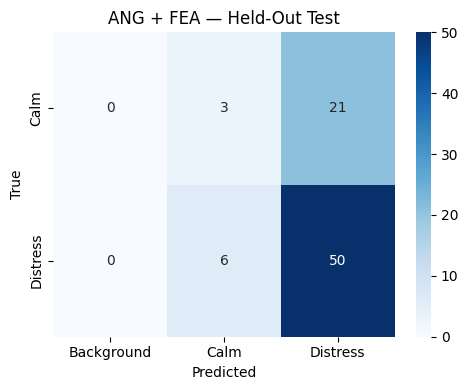

In [ ]:
cm = np.array([
    [
        sum(t == 1 and p == 0 for t, p in zip(y_true, y_pred)),
        sum(t == 1 and p == 1 for t, p in zip(y_true, y_pred)),
        sum(t == 1 and p == 2 for t, p in zip(y_true, y_pred)),
    ],
    [
        sum(t == 2 and p == 0 for t, p in zip(y_true, y_pred)),
        sum(t == 2 and p == 1 for t, p in zip(y_true, y_pred)),
        sum(t == 2 and p == 2 for t, p in zip(y_true, y_pred)),
    ],
])

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Background", "Calm", "Distress"],
    yticklabels=["Calm", "Distress"],
)

plt.title("ANG + FEA — Held-Out Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()

save_path = OUTPUT_DIR / "confusion_matrix_anger_fear.png"
plt.savefig(save_path, dpi=150)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
)

accuracy=accuracy_score(y_true,y_pred)

macro_f1=f1_score(
    y_true,y_pred,
    labels=[0,1],
    average="macro",
    zero_division=0,
)

macro_recall=recall_score(
    y_true,y_pred,
    labels=[0,1],
    average="macro",
    zero_division=0,
)

y_true_binary=np.array(y_true)
y_pred_binary=np.array(y_pred)

tn,fp,fn,tp=confusion_matrix(
    y_true_binary,
    y_pred_binary,
    labels=[0,1],
).ravel()

sensitivity=tp/(tp+fn) if (tp+fn)>0 else 0.0
specificity=tn/(tn+fp) if (tn+fp)>0 else 0.0

balanced_accuracy=balanced_accuracy_score(
    y_true_binary,
    y_pred_binary,
)

pred_df=pd.DataFrame(prediction_rows)
y_score=pred_df["prob_distress"].to_numpy()

auc_roc=roc_auc_score(
    y_true_binary,
    y_score,
)

print(f"Files evaluated : {len(y_true)}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0,1],
        target_names=["Calm speech","Anger + Fear"],
        zero_division=0,
        digits=4,
    )
)

print(f"\nTrue Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

print(f"\nSensitivity / Recall (Anger + Fear): {sensitivity:.4f}")
print(f"Specificity (Calm correctly rejected): {specificity:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Files evaluated : 80
Accuracy        : 0.6625
Macro F1        : 0.4846
Macro Recall    : 0.5089

Classification Report:

              precision    recall  f1-score   support

 Calm speech     0.3333    0.1250    0.1818        24
Amger + Fear     0.7042    0.8929    0.7874        56

    accuracy                         0.6625        80
   macro avg     0.5188    0.5089    0.4846        80
weighted avg     0.5930    0.6625    0.6057        80


True Negatives  (TN): 3
False Positives (FP): 21
False Negatives (FN): 6
True Positives  (TP): 50

Sensitivity / Recall (Anger + Fear): 0.8929
Specificity (Calm correctly rejected): 0.1250
Balanced Accuracy: 0.5089
AUC-ROC: 0.6473
